# Customer Intelligence: RFM Segmentation & Churn Risk Modeling

## Objective
This project performs customer segmentation using RFM methodology and estimates churn risk and customer 
lifetime value (CLV) to support retention strategy decisions.

In [13]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# Load Dataset
df = pd.read_csv(r"C:\Users\fakhr\OneDrive\Bureau\Formation Data Analyst\Python\Exemple projet\Customer-Segmentation-main\marketing_campaign.csv",sep="\t")
pd.set_option('display.max_columns',None)
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [15]:
# Number of lines 
df.dropna(how="all").shape[0] 

2240

In [16]:
# Calculating the number of unique values ​​per column
df.nunique()

ID                     2240
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             663
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         558
MntFishProducts         182
MntSweetProducts        177
MntGoldProds            213
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

In [17]:
# Calculating the number of missing values per column
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [18]:
# Create Age variable based on dataset reference year (2014)
df['Age']= 2014 - df['Year_Birth']

In [19]:
# Create age groups for segmentation analysis
bins = [0, 18, 25, 30, 35, 40, 45, 50, 55, 60, 65, 125]
Label_Age = ['<18','18-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-64','65+']
df['Group Age']=pd.cut(df['Age'],bins=bins,labels=Label_Age,right=True)

In [20]:
# Inspect unique education levels
df['Education'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [21]:
# Standardize education level labels for clarity and consistency
df['Education']=df['Education'].replace({
    'Basic':'Basic Education',
    '2n Cycle':'High School',
    'Graduation':'Bachelor\'s Degree',
    'Master':'Master\'s Degree',
    'PhD':'Doctorate'
})

In [22]:
# Inspect unique marital status categories
df['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [23]:
# Standardize marital status categories for consistency
df['Marital_Status']=df['Marital_Status'].replace({
    'Together':'Married',
    'Widow':'Widowed',
    'Alone':'Single',
    'Absurd':'Other',
    'YOLO':'Other'
})

In [24]:
# Create family size variable based on household composition
df['Size Family']=df['Kidhome']+df['Teenhome'] + df['Marital_Status'].map({
    'Single':1,'Married':2,'Divorced':1,'Widowed':1,'Other':1
})

In [25]:
# Define reference date (last transaction date in dataset)
from datetime import date
last_date=pd.Timestamp("2014-10-04")

# Convert customer enrollment date to datetime format
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True,format="mixed",errors="coerce")

# Calculate customer seniority (tenure in months)
df['Seniority']=(
    (last_date-df["Dt_Customer"]).dt.days/30
).round(2)

In [26]:
#Create Seniority segment
cut_labels_Seniority = ['New customers', 'Discovering customers', 'Experienced customers', 'Old customers']
df['Seniority_group'] = pd.qcut(df['Seniority'], q=4, labels=cut_labels_Seniority)

In [27]:
# Rename spending columns for clarity and readability
df = df.rename(columns = {"MntWines": "Wines",
                            "MntFruits":"Fruits",
                            "MntMeatProducts":"Meat",
                            "MntFishProducts":"Fish",
                            "MntSweetProducts":"Sweets",
                            "MntGoldProds":"Premium"})

In [28]:
# Calculate total spending across product categories (Monetary value)
df['Monetary']=df.iloc[:,9:15].sum(axis=1)

In [29]:
# Remove extreme income outliers by setting unrealistic values to NaN
df.loc[df['Income'] > 600000, 'Income'] = np.nan

In [30]:
#Create Income segment
cut_labels_Income = ['Low income', 'Low to medium income', 'Medium to high income', 'High income']
df['Income group'] = pd.qcut(df['Income'], q=4, labels=cut_labels_Income)

In [31]:
# Add category for missing income values
df['Income group'] = df['Income group'].cat.add_categories('Income unknown')

# Assign 'Income unknown' to customers with missing income
df.loc[df['Income'].isna(), 'Income group'] = 'Income unknown'

In [32]:
# Calculate total purchase frequency across all sales channels
df['Frequency'] = df[['NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].sum(axis=1)


In [33]:
# Rename purchase-related columns for better readability
df=df.rename(columns = {
          'NumDealsPurchases':'Deals Purchases',
          'NumWebPurchases':'Web Purchases',
          'NumCatalogPurchases':'Catalog Purchases',
          'NumStorePurchases':'Store Purchases',
          'NumWebVisitsMonth':'Web Visits Month'
})

In [35]:
# Drop unused or non-relevant columns for segmentation analysis
df = df.drop(['Kidhome','Teenhome','Z_CostContact','Z_Revenue','Complain',
             'AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5',
              'Response'], axis=1)


In [36]:
# Create RFM dataset for segmentation analysis
nvtable = ['ID','Recency','Frequency','Monetary']
df1=df[nvtable].copy()

In [37]:
# Compute quartiles for RFM scoring thresholds
quantiles = df1.quantile(q=[0.25, 0.5, 0.75])
quantiles = quantiles.to_dict()

In [38]:
# Define scoring function for Recency (lower recency = higher score)
def r_score(x, q):
    if x <= q[0.25]:
        return 4
    elif x <= q[0.50]:
        return 3
    elif x <= q[0.75]:
        return 2
    else:
        return 1

# Define scoring function for Frequency and Monetary (higher value = higher score)
def fm_score(x, q):
    if x <= q[0.25]:
        return 1
    elif x <= q[0.50]:
        return 2
    elif x <= q[0.75]:
        return 3
    else:
        return 4


In [39]:
# Apply RFM scoring to each customer
df1['R']=df1['Recency'].apply(r_score,args=(quantiles['Recency'],))
df1['F'] = df1['Frequency'].apply(fm_score, args=(quantiles['Frequency'],))
df1['M'] = df1['Monetary'].apply(fm_score, args=(quantiles['Monetary'],))

In [40]:
# Create combined RFM score and total score
df1['RFM Score'] = (
    df1['R'].astype(str) +
    df1['F'].astype(str) +
    df1['M'].astype(str)
)
df1['RFM Total'] = df1[['R','F','M']].sum(axis=1)

In [41]:
# Compute average of Frequency and Monetary scores
df1['FM Score'] = df1[['F','M']].mean(axis=1)

# Define RFM-based customer segmentation logic
def rfm_segment_pro(row):
    if row['R'] >= 3 and row['FM Score'] >= 3:
        return 'Stars'
    elif row['R'] >= 3 and row['FM Score'] < 3:
        return 'High potential'
    elif row['R'] < 3 and row['FM Score'] >= 3:
        return 'Need attention'
    else:
        return 'Leaky bucket'

# Assign segment label to each customer
df1['Segment'] = df1.apply(rfm_segment_pro, axis=1)

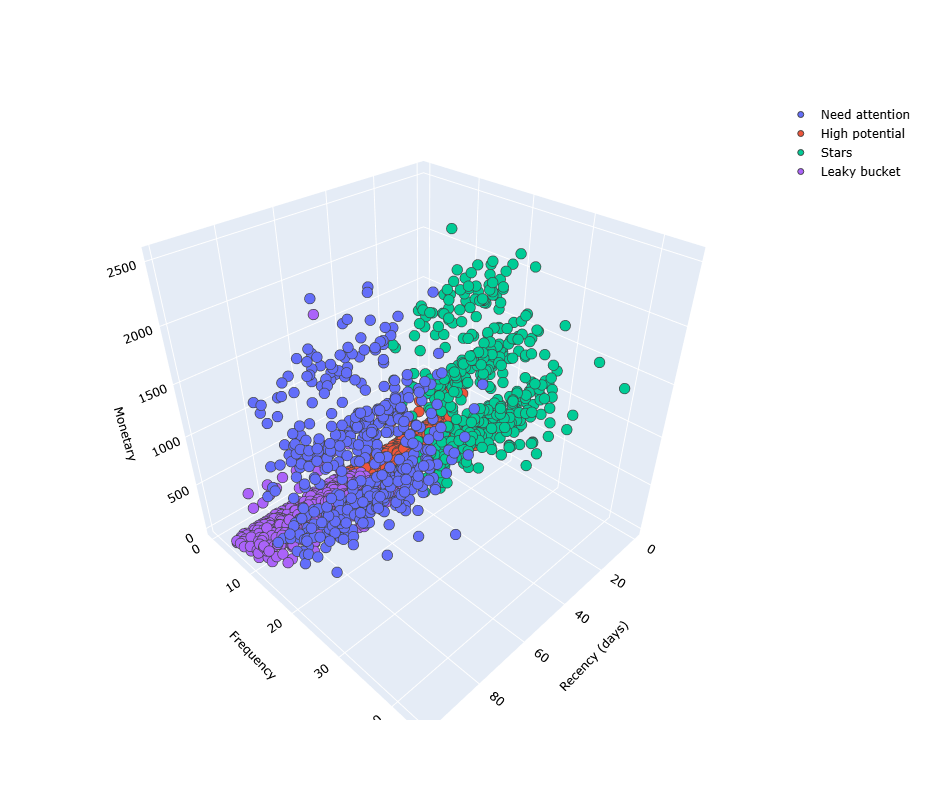

In [42]:
# Visualize RFM segments in a 3D space (Recency, Frequency, Monetary)
import plotly.graph_objects as go

PLOT = go.Figure()

# Add one 3D scatter trace per customer segment
for C in df1['Segment'].unique():
    PLOT.add_trace(
        go.Scatter3d(
            x=df1[df1['Segment'] == C]['Recency'],
            y=df1[df1['Segment'] == C]['Frequency'],
            z=df1[df1['Segment'] == C]['Monetary'],
            mode='markers',
            marker=dict(
                size=6,
                line=dict(width=1)
            ),
            name=str(C)
        )
    )

# Customize hover information
PLOT.update_traces(
    hovertemplate=
    'Recency: %{x}<br>'
    'Frequency: %{y}<br>'
    'Monetary: %{z}<extra></extra>'
)

# Configure layout and axis titles
PLOT.update_layout(
    width=800,
    height=800,
    autosize=True,
    showlegend=True,
    scene=dict(
        xaxis=dict(
            title=dict(
                text='Recency (days)',
                font=dict(size=12)
            )
        ),
        yaxis=dict(
            title=dict(
                text='Frequency',
                font=dict(size=12)
            )
        ),
        zaxis=dict(
            title=dict(
                text='Monetary',
                font=dict(size=12)
            )
        )
    ),
    font=dict(color='black', size=12)
)

PLOT.show()


In [43]:
# Define custom order for RFM segments
order = ['Stars','High potential','Need attention','Leaky bucket']

In [44]:
# Count customers per segment in defined order
segment_count = df1['Segment'].value_counts().reindex(order)
segment_count

Segment
Stars             526
High potential    596
Need attention    535
Leaky bucket      583
Name: count, dtype: int64

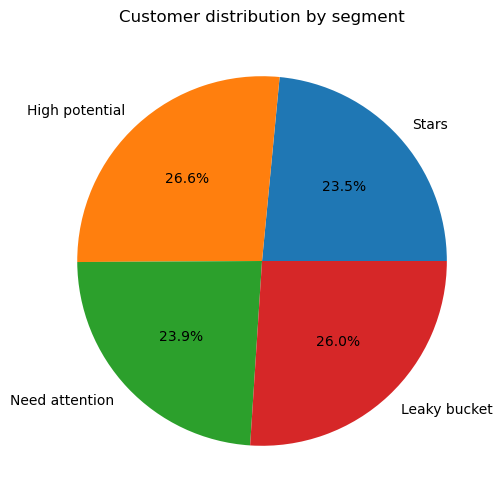

In [45]:
# Visualize customer distribution by RFM segment
segment_count.plot.pie(
    autopct='%1.1f%%',     # affiche les pourcentages
    figsize=(6,6),
    title='Customer distribution by segment',
    ylabel=''              
)
plt.show()

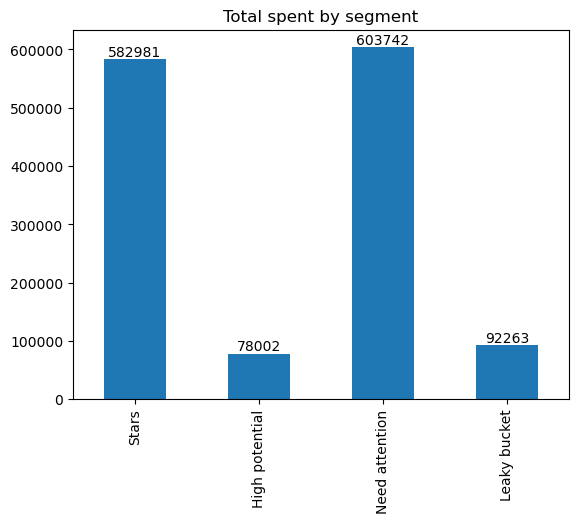

In [46]:
# Analyze total revenue contribution by segment
gr1 = df1.groupby('Segment')['Monetary'].sum().sort_values(ascending=False).reindex(order)
ax1 = gr1.plot(kind='bar',title='Total spent by segment',xlabel='',ylabel='')

# Display value labels on bars
for container in ax1.containers:
    ax1.bar_label(container)

In [47]:
# Analyze average customer spending by segment
gr2 = df1.groupby('Segment')['Monetary'].mean().round(2).reindex(order)
gr2

Segment
Stars             1108.33
High potential     130.88
Need attention    1128.49
Leaky bucket       158.26
Name: Monetary, dtype: float64

In [48]:
# Add additional demographic and behavioral variables to RFM dataset
cols_to_add=['Group Age','Size Family','Education','Marital_Status','Income','Seniority_group','Income group',
      'Wines','Fruits','Meat','Fish','Sweets','Premium','Deals Purchases','Seniority']
df1[cols_to_add] = df[cols_to_add]

In [49]:
# Identify dominant income group per segment
Income_profile = (
    df1
    .groupby(['Segment', 'Income group'],observed=False)
    .size()
    .reset_index(name='count')
    .sort_values(['Segment', 'count'], ascending=[True, False])
    .drop_duplicates('Segment')
    .set_index('Segment')['Income group']
).reindex(order)

Income_profile

Segment
Stars             High income
High potential     Low income
Need attention    High income
Leaky bucket       Low income
Name: Income group, dtype: category
Categories (5, object): ['Low income' < 'Low to medium income' < 'Medium to high income' < 'High income' < 'Income unknown']

In [50]:
# Identify dominant age group per segment
age_profile = (
    df1
    .groupby(['Segment', 'Group Age'],observed=False)
    .size()
    .reset_index(name='count')
    .sort_values(['Segment', 'count'], ascending=[True, False])
    .drop_duplicates('Segment')
    .set_index('Segment')['Group Age']
)

age_profile

Segment
High potential    40-44
Leaky bucket      35-39
Need attention    40-44
Stars             35-39
Name: Group Age, dtype: category
Categories (11, object): ['<18' < '18-24' < '25-29' < '30-34' ... '50-54' < '55-59' < '60-64' < '65+']

In [51]:
# Calculate average income per segment
income_mean = (df1.groupby('Segment')['Income']
                 .mean()
                 .round(0)
                 .reindex(order))
income_mean

Segment
Stars             68313.0
High potential    36805.0
Need attention    67831.0
Leaky bucket      37971.0
Name: Income, dtype: float64

In [52]:
# Identify dominant family size per segment
family_profile = (
    df1
    .groupby(['Segment', 'Size Family'])
    .size()
    .reset_index(name='count')
    .sort_values(['Segment', 'count'], ascending=[True, False])
    .drop_duplicates('Segment')
    .set_index('Segment')['Size Family']
)

family_profile


Segment
High potential    3
Leaky bucket      3
Need attention    2
Stars             2
Name: Size Family, dtype: int64

In [53]:
# Identify dominant education level per segment
Education_profile = (
    df1
    .groupby(['Segment', 'Education'])
    .size()
    .reset_index(name='count')
    .sort_values(['Segment', 'count'], ascending=[True, False])
    .drop_duplicates('Segment')
    .set_index('Segment')['Education']
)

Education_profile


Segment
High potential    Bachelor's Degree
Leaky bucket      Bachelor's Degree
Need attention    Bachelor's Degree
Stars             Bachelor's Degree
Name: Education, dtype: object

In [54]:
# Identify dominant seniority group per segment
Seniority_profile = (
    df1
    .groupby(['Segment', 'Seniority_group'],observed=False)
    .size()
    .reset_index(name='count')
    .sort_values(['Segment', 'count'], ascending=[True, False])
    .drop_duplicates('Segment')
    .set_index('Segment')['Seniority_group']
).reindex(order)

Seniority_profile


Segment
Stars             Old customers
High potential    New customers
Need attention    Old customers
Leaky bucket      New customers
Name: Seniority_group, dtype: category
Categories (4, object): ['New customers' < 'Discovering customers' < 'Experienced customers' < 'Old customers']

In [55]:
# Calculate average spending per product category by segment
product=['Wines','Fruits','Meat','Fish','Sweets','Premium']
product_profile = (
    df1
    .groupby('Segment')[product]
    .mean()
    .round(1)
)

product_profile



,Wines,Fruits,Meat,Fish,Sweets,Premium
Segment,,,,,,
High potential,60.9,6.7,29.2,10.0,5.8,18.2
Leaky bucket,71.3,7.6,41.1,11.1,8.0,19.1
Need attention,577.4,46.6,313.4,67.4,50.6,73.1
Stars,559.0,48.6,313.5,67.6,48.3,71.3


In [56]:
# Identify top 3 product categories per segment
top_products = {}

for segment in df1['Segment'].unique():
    top_products[segment] = (
        product_profile.loc[segment]
        .sort_values(ascending=False)
        .head(3)
        .index
        .tolist()
    )

top_products


{'Need attention': ['Wines', 'Meat', 'Premium'],
 'High potential': ['Wines', 'Meat', 'Premium'],
 'Stars': ['Wines', 'Meat', 'Premium'],
 'Leaky bucket': ['Wines', 'Meat', 'Premium']}

In [57]:
# Create consolidated segment profile summary
segment_description = pd.DataFrame({
    'Age dominant': age_profile,
    'Income dominant': Income_profile,
    'Family dominant': family_profile,
    'Education dominant':Education_profile,
    'Top products': pd.Series(top_products)
}).reindex(order)

segment_description


,Age dominant,Income dominant,Family dominant,Education dominant,Top products
Stars,35-39,High income,2,Bachelor's Degree,"[Wines, Meat, Premium]"
High potential,40-44,Low income,3,Bachelor's Degree,"[Wines, Meat, Premium]"
Need attention,40-44,High income,2,Bachelor's Degree,"[Wines, Meat, Premium]"
Leaky bucket,35-39,Low income,3,Bachelor's Degree,"[Wines, Meat, Premium]"


In [58]:
# Analyze average behavioral metrics per segment
behavior_profile = (
    df1
    .groupby('Segment')
    .agg(
        avg_frequency=('Frequency', 'mean'),
        avg_monetary=('Monetary', 'mean'),
        avg_income=('Income','mean')
    )
    .round(2)
).reindex(order)

behavior_profile


,avg_frequency,avg_monetary,avg_income
Segment,,,
Stars,21.81,1108.33,68312.75
High potential,8.54,130.88,36804.67
Need attention,21.63,1128.49,67831.12
Leaky bucket,8.85,158.26,37970.73


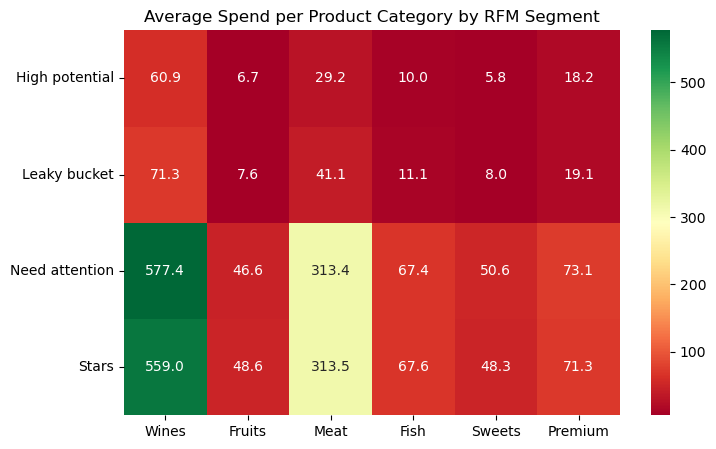

In [94]:
# Visualize average spending per product category by segment
import seaborn as sns
plt.figure(figsize=(8,5))
sns.heatmap(
    product_profile,
    annot=True,
    cmap='RdYlGn',
    fmt='.1f'
)
plt.title('Average Spend per Product Category by RFM Segment')
plt.xlabel('')
plt.ylabel('')
plt.show()


### Insight

Spending intensity differs significantly across RFM segments and product categories.

- **Stars** and **Need Attention** customers show very high spending in Wines and Meat, indicating strong contribution to premium and high-margin categories.
- Lower-value segments such as **High Potential** and **Leaky Bucket** display substantially lower spending across all product categories.
- Premium and specialty products are primarily driven by top-value customers.

This confirms that a small number of high-value segments generate disproportionate revenue across key product categories, reinforcing the importance of targeted retention strategies.

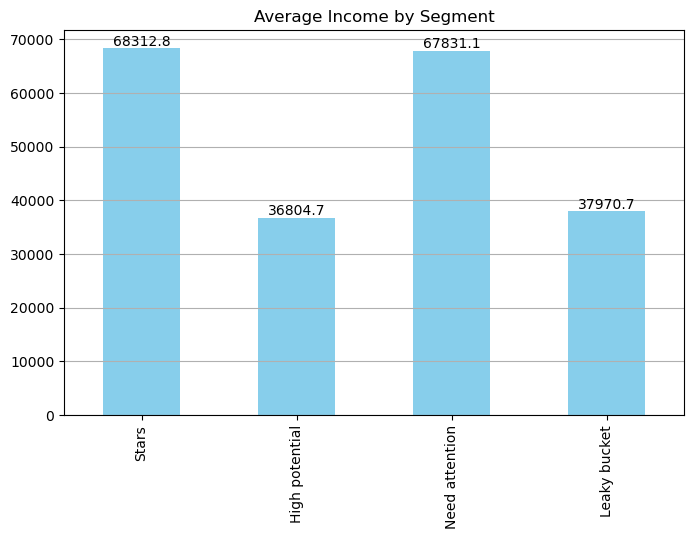

In [64]:
# Visualize average income by segment
ax= behavior_profile['avg_income'].plot(kind='bar', figsize=(8,5), color='skyblue')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Average Income by Segment")
plt.xlabel("")
plt.ylabel("")
plt.grid(axis='y')
plt.show()

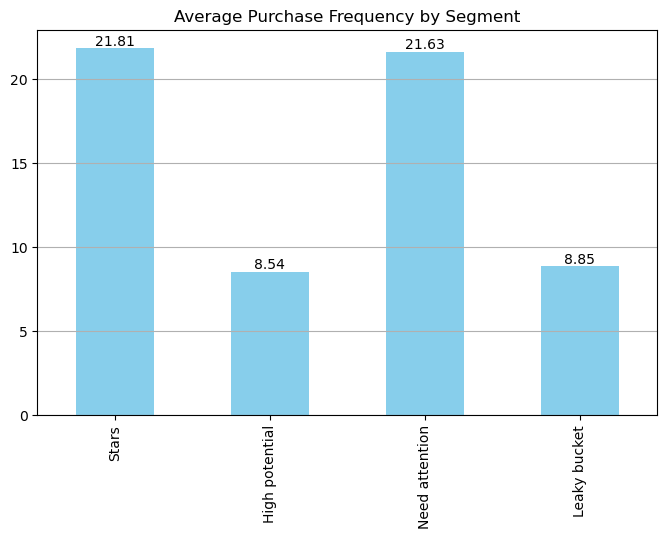

In [65]:
# Visualize average purchase frequency by segment
ax= behavior_profile['avg_frequency'].plot(kind='bar', figsize=(8,5), color='skyblue')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Average Purchase Frequency by Segment")
plt.xlabel("")
plt.ylabel("")
plt.grid(axis='y')
plt.show()

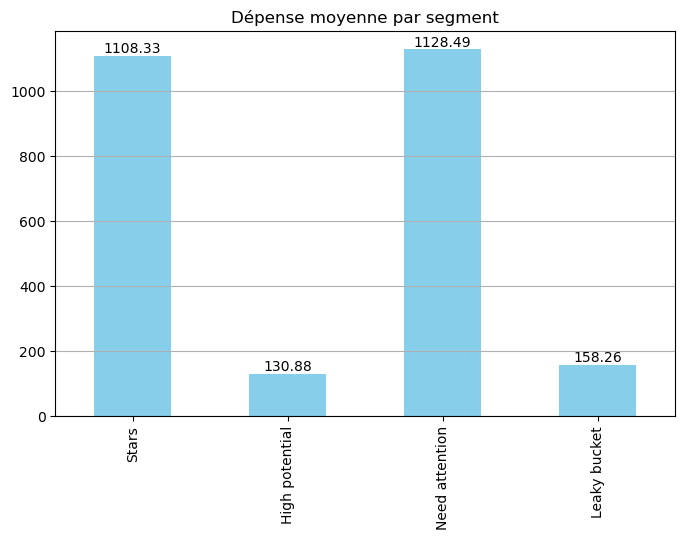

In [67]:
# Visualize average monetary value by segment
ax= behavior_profile['avg_monetary'].plot(kind='bar', figsize=(8,5), color='skyblue')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Dépense moyenne par segment")
plt.xlabel("")
plt.ylabel("")
plt.grid(axis='y')
plt.show()

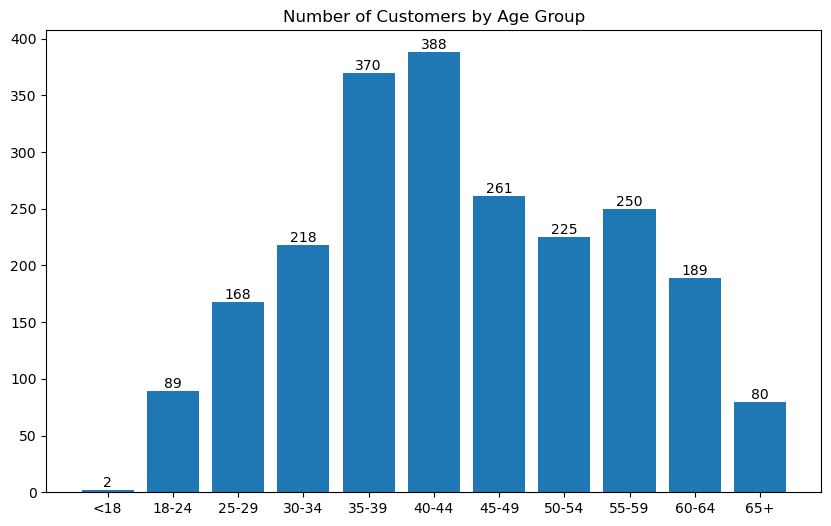

In [66]:
# Visualize customer distribution by age group
import matplotlib.pyplot as plt

order_Age = ['<18','18-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-64','65+']

# Count customers per age group
counts = df1['Group Age'].value_counts().reindex(order_Age, fill_value=0)

# Create bar chart
fig, ax = plt.subplots(figsize=(10,6))
bars = ax.bar(counts.index, counts.values)

# Add value labels
ax.bar_label(bars)
ax.set_title('Number of Customers by Age Group')
plt.show()


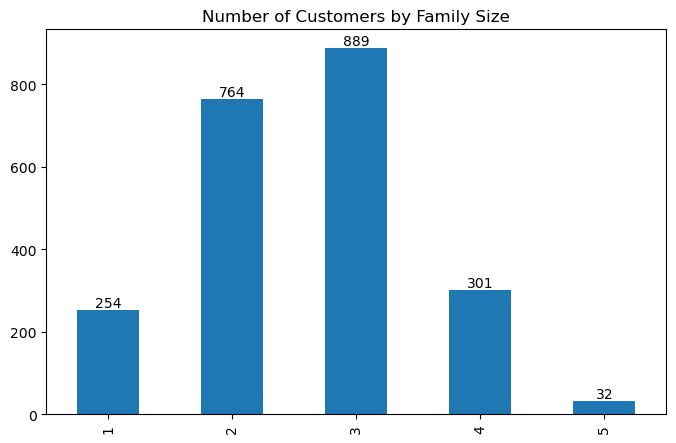

In [68]:
# Visualize customer distribution by family size
ax=df1['Size Family'].value_counts().sort_index().plot(kind="bar", figsize=(8,5), title="Number of Customers by Family Size")
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("")
plt.ylabel("")
plt.show()

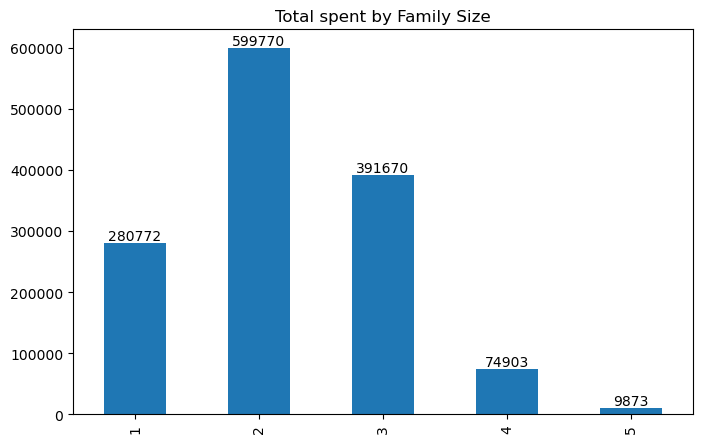

In [69]:
# Analyze total spending by family size
ax = df1.groupby('Size Family', observed=False)['Monetary'].sum().sort_index().plot(kind="bar", figsize=(8,5),title="Total spent by Family Size")
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("")
plt.ylabel("")
plt.show()


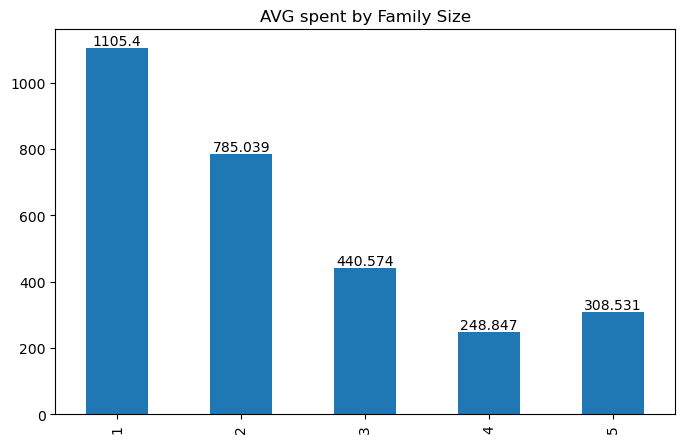

In [70]:
# Analyze average spending by family size
ax = df1.groupby('Size Family', observed=False)['Monetary'].mean().sort_index().plot(kind="bar", figsize=(8,5),title="AVG spent by Family Size")
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("")
plt.ylabel("")
plt.show()


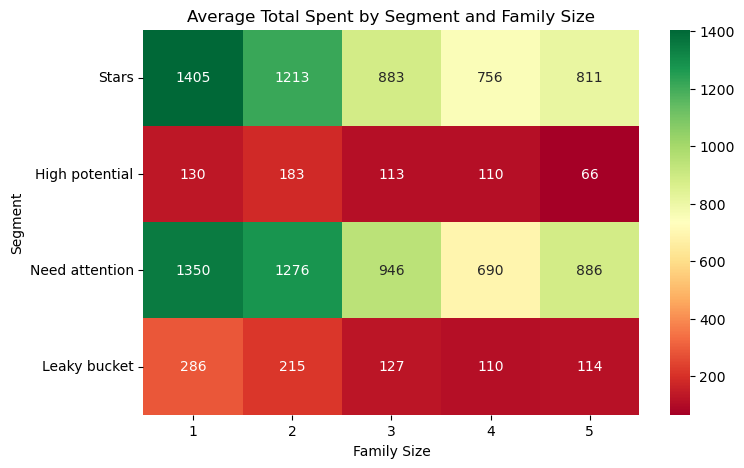

In [71]:
# Create pivot table: Segment × Family_Size (average spending)
import seaborn as sns
heat_data = df1.pivot_table(
    index='Segment',
    columns='Size Family',
    values='Monetary',
    aggfunc='mean'
).reindex(order)

# Visualize heatmap
plt.figure(figsize=(8,5))
sns.heatmap(heat_data, annot=True, fmt=".0f", cmap="RdYlGn")
plt.title("Average Total Spent by Segment and Family Size")
plt.ylabel("Segment")
plt.xlabel("Family Size")
plt.show()


### Insight

Spending patterns vary significantly across both RFM segments and family size.

- **Stars** and **Need Attention** customers generate the highest spending levels across most family sizes.
- Smaller households (family size 1–2) tend to generate higher average spending, particularly among high-value segments.
- Larger households (size 4–5) show lower average spending per customer across most segments.

This suggests that high-value customers are not necessarily associated with larger family sizes. 
Household size alone does not drive lifetime value — segment behavior plays a stronger role.

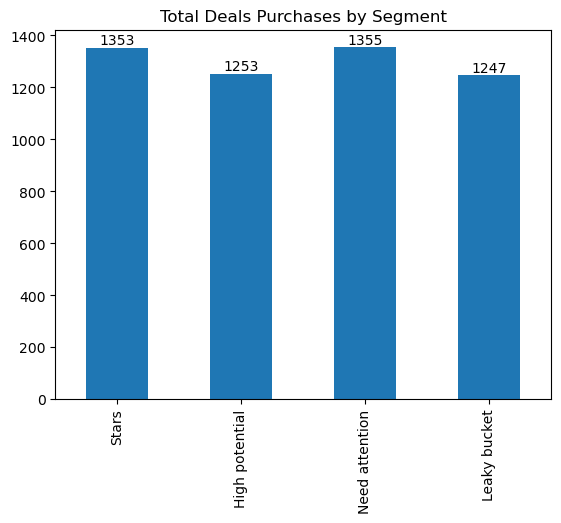

In [72]:
# Analyze total deal purchases by segment
gr1 = df1.groupby('Segment')['Deals Purchases'].sum().sort_values(ascending=False).reindex(order)
ax1 = gr1.plot(kind='bar',title='Total Deals Purchases by Segment',xlabel='',ylabel='')
for container in ax1.containers:
    ax1.bar_label(container)

In [73]:
df1.head()

,ID,Recency,Frequency,Monetary,R,F,M,RFM Score,RFM Total,FM Score,Segment,Group Age,Size Family,Education,Marital_Status,Income,Seniority_group,Income group,Wines,Fruits,Meat,Fish,Sweets,Premium,Deals Purchases,Seniority
0,5524,58,25,1617,2,4,4,244,10,4.0,Need attention,55-59,1,Bachelor's Degree,Single,58138.0,Old customers,Medium to high income,635,88,546,172,88,88,3,25.33
1,2174,38,6,27,3,1,1,311,5,1.0,High potential,55-59,3,Bachelor's Degree,Single,46344.0,New customers,Low to medium income,11,1,6,2,1,6,2,7.00
2,4141,26,21,776,3,3,3,333,9,3.0,Stars,45-49,2,Bachelor's Degree,Married,71613.0,Discovering customers,High income,426,49,127,111,21,42,1,13.63
3,6182,26,8,53,3,1,1,311,5,1.0,High potential,25-29,3,Bachelor's Degree,Married,26646.0,New customers,Low income,11,4,20,10,3,5,2,7.87
4,5324,94,19,422,1,3,3,133,7,3.0,Need attention,30-34,3,Doctorate,Married,58293.0,New customers,Medium to high income,173,43,118,46,27,15,5,8.60


In [74]:
# Combine segment descriptive and behavioral profiles
final_profile = pd.concat([segment_description, behavior_profile], axis=1)

final_profile


,Age dominant,Income dominant,Family dominant,Education dominant,Top products,avg_frequency,avg_monetary,avg_income
Stars,35-39,High income,2,Bachelor's Degree,"[Wines, Meat, Premium]",21.81,1108.33,68312.75
High potential,40-44,Low income,3,Bachelor's Degree,"[Wines, Meat, Premium]",8.54,130.88,36804.67
Need attention,40-44,High income,2,Bachelor's Degree,"[Wines, Meat, Premium]",21.63,1128.49,67831.12
Leaky bucket,35-39,Low income,3,Bachelor's Degree,"[Wines, Meat, Premium]",8.85,158.26,37970.73


In [75]:
# Define behavioral interpretation per segment
behavior_map = {
    "Stars": (
        "Very frequent purchases, high spending and strong preference for "
        "premium products. Highly loyal and high lifetime value customers."
    ),
    "High potential": (
        "Low spending and moderate frequency. Customers show interest in key "
        "products but have not yet reached their full value potential."
    ),
    "Need attention": (
        "High spending and high purchase frequency but reduced recent activity. "
        "Customers are valuable but at risk of churn."
    ),
    "Leaky bucket": (
        "Low frequency and low spending behavior. Customers show weak engagement "
        "and limited profitability."
    )
}
# Define recommended strategic actions per segment
action_map = {
    "Stars": (
        "Focus on retention strategies: loyalty programs, exclusive offers, "
        "early access to new products, and personalized communication."
    ),
    "High potential": (
        "Encourage frequency growth through targeted promotions, bundle offers "
        "and personalized recommendations to increase basket size."
    ),
    "Need attention": (
        "Prioritize reactivation campaigns: personalized discounts, reminders, "
        "special incentives, and churn-prevention strategies."
    ),
    "Leaky bucket": (
        "Limit marketing investment. Use automated promotions and price-based "
        "offers to test reactivation potential."
    )
}
# Create strategic summary table
conclusion_table = pd.DataFrame({
    "Customer behavior": pd.Series(behavior_map),
    "Recommended actions": pd.Series(action_map)
}).reindex(order)

conclusion_table

,Customer behavior,Recommended actions
Stars,"Very frequent purchases, high spending and str...",Focus on retention strategies: loyalty program...
High potential,Low spending and moderate frequency. Customers...,Encourage frequency growth through targeted pr...
Need attention,High spending and high purchase frequency but ...,Prioritize reactivation campaigns: personalize...
Leaky bucket,Low frequency and low spending behavior. Custo...,Limit marketing investment. Use automated prom...


In [76]:
# Define concise behavioral summary per segment
behavior_short = {
    "Stars": "Highly loyal, frequent buyers with high spending",
    "High potential": "Moderate engagement with strong growth potential",
    "Need attention": "High-value customers at risk of churn",
    "Leaky bucket": "Low engagement and low profitability"
}
# Define concise recommended actions per segment
actions_short = {
    "Stars": "Retention, VIP programs, exclusive offers",
    "High potential": "Increase frequency and basket size",
    "Need attention": "Reactivation and churn prevention",
    "Leaky bucket": "Low-cost promotions, limited investment"
}
# Create strategic summary table
conclusion_table = pd.DataFrame({
    "Customer behavior": pd.Series(behavior_short),
    "Recommended actions": pd.Series(actions_short)
}).reindex(order)

conclusion_table


,Customer behavior,Recommended actions
Stars,"Highly loyal, frequent buyers with high spending","Retention, VIP programs, exclusive offers"
High potential,Moderate engagement with strong growth potential,Increase frequency and basket size
Need attention,High-value customers at risk of churn,Reactivation and churn prevention
Leaky bucket,Low engagement and low profitability,"Low-cost promotions, limited investment"


In [77]:
# ============================================
# CLV & Recency-Weighted Customer Value
# ============================================

# Filter valid customers (avoid division by zero and invalid tenure)
df1 = df1.loc[
    (df1["Frequency"] > 0) & (df1["Seniority"] > 0)
].copy()

# Estimate CLV components (average order value, annual frequency, CLV)
df1["Avg_Order_Value"] = (df1["Monetary"] / df1["Frequency"]).round(2)
df1["Annual_Frequency"] = (df1["Frequency"] / df1["Seniority"] * 12).round(2)
df1["CLV"] = (df1["Avg_Order_Value"] * df1["Annual_Frequency"] * (df1["Seniority"] / 12)).round(2)

# Normalize Recency to [0,1] for churn risk weighting
den = df1["Recency"].max() - df1["Recency"].min()

if den == 0:
    df1["Recency_norm"] = 0.0
else:
    df1["Recency_norm"] = ((df1["Recency"] - df1["Recency"].min()) / den).round(2)

# Compute recency-weighted CLV (lower recency => higher weighted value)
df1["CLV_weighted"] = (df1["CLV"] * (1 - df1["Recency_norm"])).round(2)


In [78]:
# Segment customers based on weighted CLV (tertiles)
df1['CLV Segment']=pd.qcut(df1['CLV_weighted'],q=3,labels=["Low CLV", "Medium CLV", "High CLV"])

In [79]:
# Identify high-value customers at risk (high CLV + high recency)
at_risk_customers = df1[
    (df1["CLV Segment"] == "High CLV") &
    (df1["Recency_norm"] > 0.6)
]

# Prioritize by weighted CLV
at_risk_customers[
    ["ID", "CLV_weighted", "Recency", "Segment"]
].sort_values("CLV_weighted", ascending=False)


,ID,CLV_weighted,Recency,Segment
1492,1763,933.84,62,Need attention
943,5386,851.62,62,Need attention
1301,6024,851.62,62,Need attention
2098,1103,801.01,60,Need attention
824,5536,743.81,61,Need attention
...,...,...,...,...
1195,6283,317.88,64,Need attention
1398,3421,317.88,64,Need attention
1305,5841,316.16,61,Need attention
1505,3643,315.48,65,Leaky bucket


### Strategic Insight

High-value customers with high recency represent the highest churn risk group.  
These customers should be prioritized for targeted retention campaigns.

### Key Insight

The analysis identified 127 high-value customers with elevated recency, indicating a high churn risk.

These customers primarily belong to the **"Need Attention"** and **"Leaky Bucket"** RFM segments.

Targeted retention strategies should be implemented to prevent potential revenue loss.

In [80]:
# Analyze average weighted CLV by age group
clv_age = df1.groupby("Group Age",observed=False)["CLV_weighted"].mean().sort_values(ascending=False).round(2)
clv_age


Group Age
65+      498.87
18-24    383.04
50-54    360.18
55-59    346.12
30-34    307.43
60-64    306.01
40-44    272.14
45-49    268.72
35-39    253.94
25-29    241.23
<18       47.82
Name: CLV_weighted, dtype: float64

In [81]:
# Analyze average weighted CLV by income group
clv_income = df1.groupby("Income group",observed=False)["CLV_weighted"].mean().sort_values(ascending=False).round(2)
clv_income


Income group
High income              681.15
Medium to high income    378.31
Income unknown           175.49
Low to medium income     115.33
Low income                40.68
Name: CLV_weighted, dtype: float64

### Insight

High-income customers generate significantly higher weighted CLV, confirming the strong link between purchasing power and long-term value.

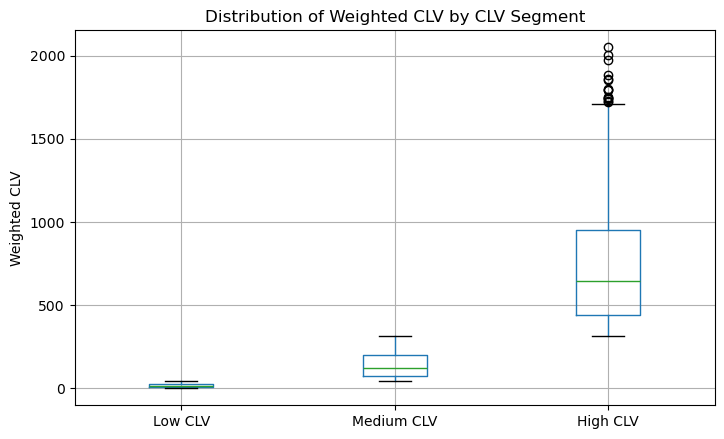

In [84]:
# Visualize distribution of weighted CLV by CLV segment
df1.boxplot(
    column="CLV_weighted",
    by="CLV Segment",
    figsize=(8,5)
)

plt.title("Distribution of Weighted CLV by CLV Segment")
plt.suptitle("")
plt.xlabel("")
plt.ylabel("Weighted CLV")
plt.show()

### Insight

The distribution clearly shows a strong separation between CLV segments.

- **High CLV customers** display significantly higher median value and a wider dispersion, indicating the presence of very high-value outliers.
- **Medium CLV customers** show moderate and more stable value patterns.
- **Low CLV customers** generate minimal long-term value with limited variability.

The wide dispersion within the High CLV segment suggests that a subset of customers contributes disproportionately to total lifetime value, reinforcing the importance of targeted retention strategies.

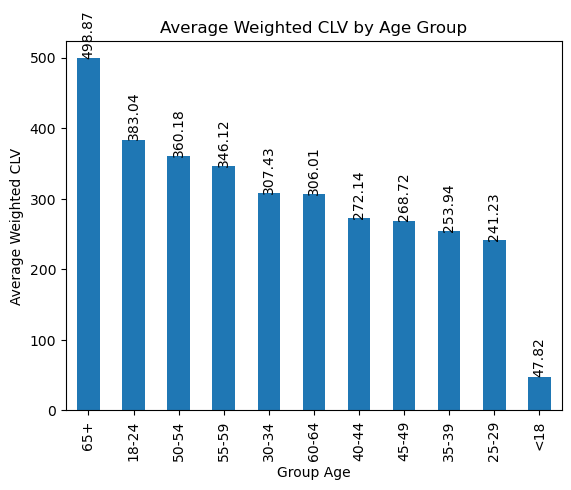

In [85]:
# Visualize average weighted CLV by age group
ax=clv_age.plot(kind="bar", title="Average Weighted CLV by Age Group")
for container in ax.containers:
    ax.bar_label(container, rotation=90)
plt.ylabel("Average Weighted CLV")
plt.show()


In [86]:
# Estimate 12-month Customer Lifetime Value (annualized CLV)
df1["CLV_12m"] = (
    df1["Avg_Order_Value"] *
    df1["Annual_Frequency"]
)


In [87]:
# Compute recency-adjusted annual CLV (churn-risk adjusted value)
df1["CLV_12m_weighted"] = df1["CLV_12m"] * (1 - df1["Recency_norm"])


In [89]:
# ============================================
# Churn Probability & Expected Value Modeling
# ============================================

from sklearn.preprocessing import MinMaxScaler

# Normalize Recency and Frequency
scaler = MinMaxScaler()

df1[["Recency_norm", "Frequency_norm"]] = scaler.fit_transform(
    df1[["Recency", "Frequency"]]
)

# Compute churn probability score
# Recency weighted at 60%, inverse frequency at 40%
df1["Churn_Prob"] = (
    0.6 * df1["Recency_norm"] +
    0.4 * (1 - df1["Frequency_norm"])
)

# Retention probability
df1["Retention_Prob"] = 1 - df1["Churn_Prob"]

# Expected annual CLV adjusted by churn risk
df1["CLV_12m_churn"] = df1["CLV_12m"] * df1["Retention_Prob"]


In [90]:
# Classify customers into churn risk levels
df1["Churn_Risk"] = pd.cut(
    df1["Churn_Prob"],
    bins=[0, 0.33, 0.66, 1],
    labels=["Low", "Medium", "High"]
)


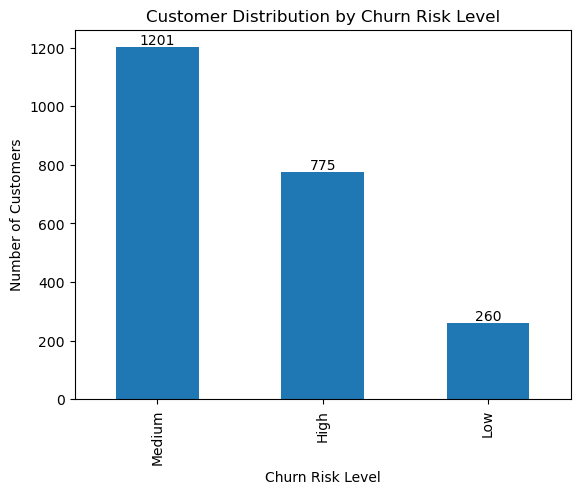

In [93]:
# Visualize churn risk distribution
ax=df1["Churn_Risk"].value_counts().plot(kind="bar")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Customer Distribution by Churn Risk Level")
plt.xlabel("Churn Risk Level")
plt.ylabel("Number of Customers")
plt.show()

### Insight

The majority of customers fall into the **Medium churn risk** category (1,201 customers), followed by the **High-risk** group (775 customers).

Although the Low-risk segment is smaller (260 customers), it represents the most stable and loyal portion of the customer base.

The presence of a substantial High-risk group suggests a significant opportunity for proactive retention strategies, particularly when combined with high lifetime value customers.

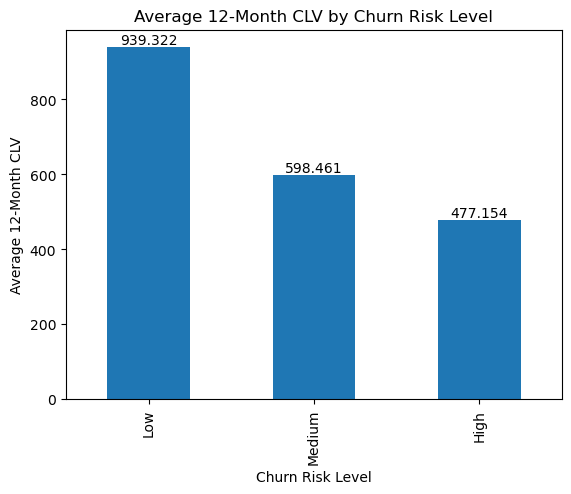

In [95]:
# Analyze average 12-month CLV by churn risk level
ax = df1.groupby("Churn_Risk",observed=False)["CLV_12m"].mean().plot(kind="bar")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Average 12-Month CLV by Churn Risk Level")
plt.xlabel("Churn Risk Level")
plt.ylabel("Average 12-Month CLV")
plt.show()


### Insight

Average 12-month CLV decreases significantly as churn risk increases.

- Low-risk customers generate the highest expected annual value (~939).
- Medium-risk customers show a moderate expected value (~598).
- High-risk customers generate the lowest projected annual value (~477).

This clear downward trend confirms the internal consistency of the churn model: 
customers with higher churn probability are associated with lower future expected value.

From a business perspective, high-risk customers still represent substantial revenue potential, 
making targeted retention strategies financially justified.

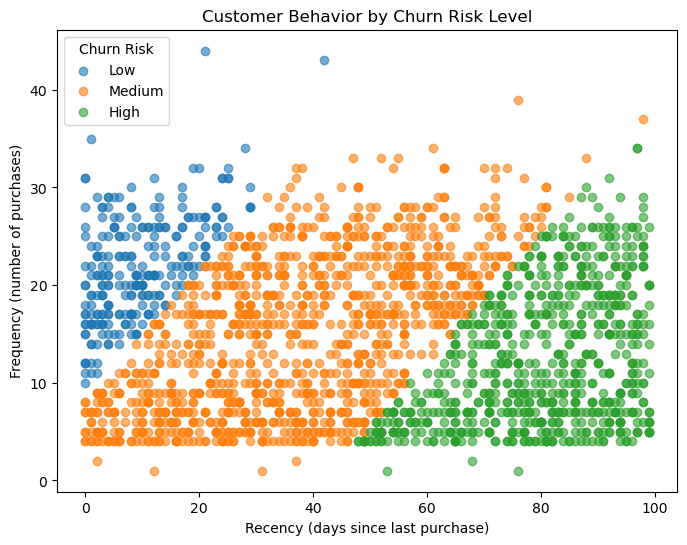

In [96]:
# Visualize customer behavior by churn risk (Recency vs Frequency)
plt.figure(figsize=(8,6))

for risk in ["Low", "Medium", "High"]:
    subset = df1[df1["Churn_Risk"] == risk]
    plt.scatter(
        subset["Recency"],
        subset["Frequency"],
        label=risk,
        alpha=0.6
    )

plt.xlabel("Recency (days since last purchase)")
plt.ylabel("Frequency (number of purchases)")
plt.title("Customer Behavior by Churn Risk Level")
plt.legend(title="Churn Risk")
plt.show()


### Insight

The scatter plot clearly highlights distinct behavioral patterns across churn risk levels.

- **Low-risk customers** cluster in the lower recency range (recent purchases) with moderate to high purchase frequency.
- **Medium-risk customers** occupy transitional zones with moderate recency and mixed frequency patterns.
- **High-risk customers** are concentrated in higher recency ranges (longer inactivity) and generally show lower purchase frequency.

This visual separation confirms that churn risk is strongly driven by declining engagement and time since last purchase.

The model effectively captures behavioral deterioration before full churn occurs.

In [97]:
# Identify top priority customers:
# High churn risk sorted by highest annual CLV
priorite = df1[
    (df1["Churn_Risk"] == "High")
].sort_values("CLV_12m", ascending=False)

priorite[[
    "ID", "CLV_12m", "Churn_Prob", "Recency", "Frequency", "Segment"
]].head(10)


,ID,CLV_12m,Churn_Prob,Recency,Frequency,Segment
1486,2939,5639.8251,0.851586,96,15,Need attention
1891,3010,4802.1490,0.750529,87,20,Need attention
1269,9400,4741.5406,0.674982,73,19,Need attention
924,8931,4564.3247,0.664412,82,26,Need attention
1800,2831,4287.8425,0.767442,99,26,Need attention
1577,9298,4070.5175,0.781254,89,18,Need attention
45,1371,3611.2800,0.696829,72,16,Need attention
513,6036,3445.8778,0.705285,78,19,Need attention
1812,8093,3354.6002,0.715433,72,14,Leaky bucket
1993,10164,3310.2108,0.715011,75,16,Need attention


### Churn Risk & Value Prioritization

Customer churn risk was visualized using recency and frequency behavioral patterns.

By combining churn probability with 12-month CLV, high-value customers requiring immediate retention actions were successfully identified.

### RFM-Based Risk Identification

RFM segmentation was first applied to identify customer relationship stages.

Customers in the **"Need Attention"** and **"Leaky Bucket"** segments were flagged as potential at-risk groups.

Within these segments, 12-month CLV and churn probability were estimated to prioritize high-value customers requiring immediate retention interventions.

# Executive Summary

This project developed a comprehensive **Customer Intelligence and Churn Risk Modeling framework** using behavioral data, segmentation techniques, and value-based prioritization.

The analysis began with **RFM segmentation** to classify customers based on recency, frequency, and monetary value. This allowed the identification of distinct relationship stages, including loyal customers (“Stars”) and at-risk groups (“Need Attention” and “Leaky Bucket”).

To move beyond static segmentation, a **Customer Lifetime Value (CLV) model** was implemented. Both historical CLV and projected 12-month CLV were calculated to estimate future revenue potential. Recency-based weighting was applied to adjust value according to engagement decline.

A **churn probability score** was then constructed using normalized recency and frequency metrics. Customers were classified into Low, Medium, and High churn risk levels, enabling actionable prioritization.

By combining:

- Churn probability  
- 12-month projected CLV  
- Behavioral segmentation  

the analysis identified high-value customers with elevated churn risk who require immediate retention interventions.

## Key Strategic Findings

- Churn risk increases significantly with declining recency and lower purchase frequency.
- Expected annual CLV decreases as churn risk rises, confirming model consistency.
- A subset of high-risk customers still represents substantial projected revenue.
- Targeted retention efforts for these customers could prevent meaningful revenue loss.

## Business Impact

This framework transforms raw transactional data into:

- Customer relationship intelligence  
- Risk-adjusted value modeling  
- Actionable retention prioritization  
- Strategic marketing decision support  

The approach demonstrates how advanced analytics can directly support revenue protection and customer lifecycle management.

---

**Result:**  
A scalable customer intelligence model capable of guiding data-driven retention strategy and maximizing long-term customer value.